In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/f230042romanhussain/imdb-data/IMDB Dataset.csv
/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt


In [5]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import nltk
from nltk.corpus import stopwords


In [6]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:


imdb_path = '/kaggle/input/datasets/f230042romanhussain/imdb-data/IMDB Dataset.csv'

data = pd.read_csv(imdb_path)

print("IMDb Dataset Loaded Successfully ")
print(data.shape)
data.head()

IMDb Dataset Loaded Successfully 
(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
def preprocess_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)       # remove special chars
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

In [9]:
data['clean_review'] = data['review'].apply(preprocess_text)

In [10]:
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    data['clean_review'], data['sentiment'], test_size=0.2, random_state=42
)

In [12]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [13]:
model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred_bow = model_bow.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

BoW Accuracy: 0.8731
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4961
           1       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [15]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [16]:
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

TF-IDF Accuracy: 0.8914
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [18]:
########Module2##########

In [19]:
!pip install gensim

In [20]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [21]:
tokenized_data = [text.split() for text in data['clean_review']]

In [22]:
w2v_model = Word2Vec(
    sentences=tokenized_data,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [23]:
def get_sentence_vector(words, model):
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_sentence_vector(text.split(), w2v_model) for text in data['clean_review']])
y = data['sentiment']

In [24]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

In [25]:
model_w2v = LogisticRegression(max_iter=1000)
model_w2v.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

In [26]:
y_pred_w2v = model_w2v.predict(X_test_w2v)

print("Word2Vec Accuracy:", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v))

Word2Vec Accuracy: 0.8652
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4961
           1       0.86      0.87      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [28]:
glove_path = '/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt'

glove_dict = {}

with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

print("GloVe Loaded Successfully")
print("Total words in GloVe:", len(glove_dict))

GloVe Loaded Successfully
Total words in GloVe: 400000


In [29]:
def get_glove_vector(words):
    vectors = []
    for word in words:
        if word in glove_dict:
            vectors.append(glove_dict[word])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_glove = np.array([get_glove_vector(text.split()) for text in data['clean_review']])

In [30]:
X_train_glove, X_test_glove, y_train, y_test = train_test_split(
    X_glove, y, test_size=0.2, random_state=42
)

In [31]:
model_glove = LogisticRegression(max_iter=1000)
model_glove.fit(X_train_glove, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_glove = model_glove.predict(X_test_glove)

print("GloVe Accuracy:", accuracy_score(y_test, y_pred_glove))
print(classification_report(y_test, y_pred_glove))

GloVe Accuracy: 0.7983
              precision    recall  f1-score   support

           0       0.79      0.80      0.80      4961
           1       0.80      0.80      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



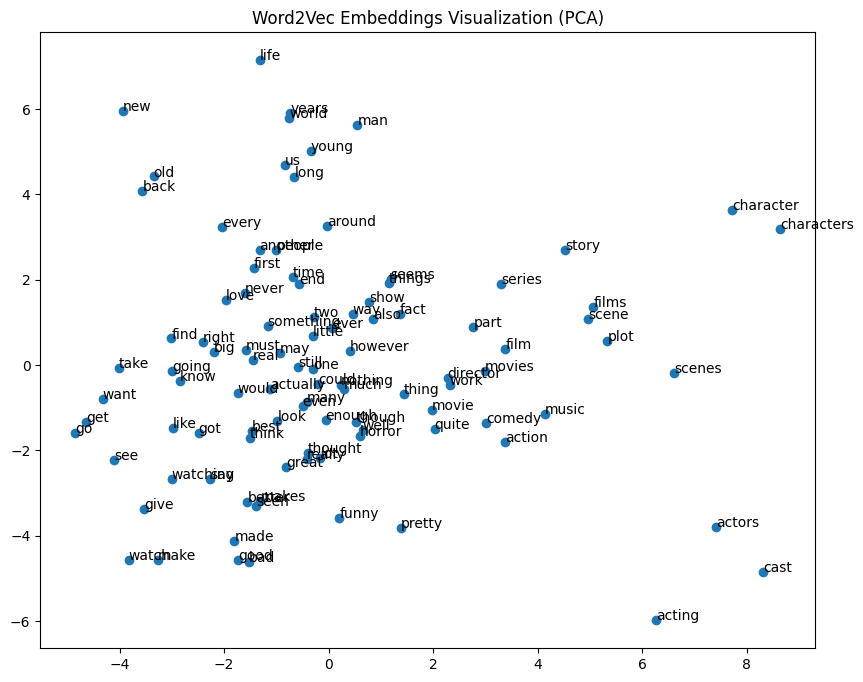

In [33]:
words = list(w2v_model.wv.index_to_key[:100])  # first 100 words
vectors = [w2v_model.wv[word] for word in words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i,0], result[i,1]))

plt.title("Word2Vec Embeddings Visualization (PCA)")
plt.show()

In [34]:
#############Module3###########

In [35]:
!pip install transformers torch

In [36]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [37]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [38]:
def get_bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    cls_embedding = outputs.last_hidden_state[:, 0, :].numpy()
    return cls_embedding[0]

In [39]:
subset = data.sample(5000, random_state=42)  # reduce size for speed

X_bert = np.array([get_bert_embedding(text) for text in subset['clean_review']])
y_bert = subset['sentiment']

In [40]:
X_train_bert, X_test_bert, y_train, y_test = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42
)

In [41]:
model_bert = LogisticRegression(max_iter=1000)
model_bert.fit(X_train_bert, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred_bert = model_bert.predict(X_test_bert)

print("BERT Accuracy:", accuracy_score(y_test, y_pred_bert))
print(classification_report(y_test, y_pred_bert))

BERT Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       506
           1       0.76      0.78      0.77       494

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



In [43]:
sentence1 = "I went to the bank to deposit money"
sentence2 = "The river bank was very beautiful"

emb1 = get_bert_embedding(sentence1)
emb2 = get_bert_embedding(sentence2)

from numpy.linalg import norm

cos_sim = np.dot(emb1, emb2) / (norm(emb1) * norm(emb2))
print("Cosine Similarity:", cos_sim)

Cosine Similarity: 0.864496
